# 09 — PEST with IWFM, Part 1: Building a Calibration

`iwfm_io.pest` covers the *setup* side of a PEST++ calibration of an
IWFM model — pure pandas, no pyemu required. This notebook opens with
the **one-call quickstart** (`pest_setup_from_model`, also exposed as
the `iwfm-io pest` command line), then walks the full build path it
is composed from:

1. **observation names** — a round-trip-safe codec
2. **observed data** — SMP files, sim-to-obs time matching
3. **budget observations** — regularizing with water-balance targets
4. **parameterization** — zones/multipliers → template files
5. **parameter write-back** — the apply step of the forward run
6. **pilot points** — FE-mesh kriging, pure numpy
7. **constrained reparameterization** — ratio chains
8. **paired output/instruction files** — consistency by construction
9. **weight balancing** — phi budgets per observation category
10. **`PestSetup`** — everything assembled into a runnable template
11. **agent orchestration** — hardlinked worker directories

**Requires:** the sample model with Results (everything runs
cross-platform; the written template runs under `pestpp-ies` if you
have it, but that is not needed here).

In [1]:
import os
import shutil
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd


def find_sample_model():
    env = os.environ.get("IWFM_SAMPLE_MODEL")
    if env:
        return Path(env)
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / ".assets" / "sample_model"
        if cand.is_dir():
            return cand
    raise FileNotFoundError("sample model not found — see notebook 01")


SAMPLE_MODEL = find_sample_model()
RESULTS_DIR = SAMPLE_MODEL / "Results"
WORK = Path(tempfile.mkdtemp(prefix="iwfm_nb09_"))
print("workspace:", WORK)

workspace: C:\Users\serca\AppData\Local\Temp\iwfm_nb09_8ask48ra


## 0. One call: `pest_setup_from_model`

Before the building blocks, the shortcut: `pest_setup_from_model` goes
straight from a model folder + observed heads to a runnable pestpp-ies
template — multiplier parameters zoned subregion × layer, observations
paired to the model's own GW hydrograph output, a hardlinked model copy,
and a generated forward run (apply → run IWFM → extract). The same call
backs the command line:

```bash
iwfm-io pest setup --model-dir <model> --obs obs.smp --dest pest_template
iwfm-io pest run   --template pest_template -n 8
iwfm-io pest analyze pest_template
```

Everything after this section shows the pieces it is composed from — the
route to take when you need pilot points, budget observations, custom
weights, or non-default parameterizations (see example
`10_pest_calibration.py` for a script version of this quickstart).

In [2]:
from iwfm_io.pest import pest_setup_from_model

# observed heads: site, datetime, value — sites matching GW hydrograph
# names. Synthesized here from the baseline run + noise (see section 2).
from iwfm_io.readers.text_output import read_hydrograph_out
from iwfm_io.wells import normalize_hydrograph_output

_hyd = normalize_hydrograph_output(
    read_hydrograph_out(RESULTS_DIR / "GWHyd.out"))
_rng = np.random.default_rng(0)
quick_obs = pd.concat([
    pd.DataFrame({"site": site, "datetime": s.index,
                  "value": s.values + _rng.normal(0, 1.0, len(s))})
    for site, s in [(f"GWHyd{i}", _hyd[i].iloc[10::45]) for i in (2, 5, 23)]
], ignore_index=True)

qs = pest_setup_from_model(
    SAMPLE_MODEL, quick_obs, WORK / "quick_template",
    parameters=("kh", "ss", "sy", "strk"), zones="subregion",
    ies_num_reals=30, noptmax=0)
qs.summary()

{'template': 'C:\\Users\\serca\\AppData\\Local\\Temp\\iwfm_nb09_8ask48ra\\quick_template',
 'case': 'iwfm_cal',
 'n_parameters': 7,
 'parameter_groups': ['kh', 'ss', 'strk', 'sy'],
 'n_observations': 243,
 'n_sites': 3,
 'n_dropped_observations': 0,
 'baseline_fit': [{'site': 'GWHyd2',
   'n': 81,
   'rmse': 0.965,
   'mean_res': 0.121,
   'r2': 0.171,
   'nse': 0.158},
  {'site': 'GWHyd23',
   'n': 81,
   'rmse': 1.098,
   'mean_res': -0.084,
   'r2': 0.186,
   'nse': 0.181},
  {'site': 'GWHyd5',
   'n': 81,
   'rmse': 0.955,
   'mean_res': -0.081,
   'r2': 0.443,
   'nse': 0.437}]}

## 1. Observation names

PEST identifies observations by name alone, so names must encode
*what/where/when* and decode back losslessly. The standard scheme is
`<type>_<location>_<yyyymmdd>`:

In [3]:
from iwfm_io.pest import decode_obs_name, decode_obs_names, encode_obs_name

name = encode_obs_name("gwh", "w1234", "2000-10-31")
print("encoded:", name)
print("decoded:", decode_obs_name(name))

# locations may contain separators; the date is recognized as the tail
print(decode_obs_name("stf_105_zcs014_13_20001031"))

encoded: gwh_w1234_20001031
decoded: ObsName(obs_type='gwh', location='w1234', time=Timestamp('2000-10-31 00:00:00'))
ObsName(obs_type='stf', location='105_zcs014_13', time=Timestamp('2000-10-31 00:00:00'))


In [4]:
# Vectorized both ways — decode a whole observation index at once
names = ["gwh_w1_20001031", "gwh_w2_20001031", "bud_dperc_sr01"]
decode_obs_names(names)

,obs_type,location,time
gwh_w1_20001031,gwh,w1,2000-10-31
gwh_w2_20001031,gwh,w2,2000-10-31
bud_dperc_sr01,bud,dperc_sr01,NaT


In [5]:
# Legacy projects use compact schemes; "grouped" reproduces the DWR
# convention <type><group><seq>_<yymmdd> built on the group/seq columns
# from notebook 08
from iwfm_io.pest import GroupSequenceScheme

loc = GroupSequenceScheme.location(67, 1)     # group 67, well 1
legacy = encode_obs_name("gwh", loc, "2000-10-31", scheme="grouped")
print(f"grouped scheme: {legacy} -> {decode_obs_name(legacy, scheme='grouped')}")

grouped scheme: gwh670001_001031 -> ObsName(obs_type='gwh', location='670001', time=Timestamp('2000-10-31 00:00:00'))


In [6]:
# validate_obs_names catches duplicates (PEST is case-insensitive),
# illegal characters, and length limits before PEST ever sees them
from iwfm_io.pest import validate_obs_names

print(validate_obs_names(["gwh_w1", "GWH_W1", "bad name"]))

["1 duplicate name(s) (case-insensitive), e.g. ['gwh_w1']", "1 name(s) with invalid characters (allowed: a-z 0-9 _ . - :), e.g. ['bad name']"]


## 2. Observed data: SMP files and sim-to-obs matching

The DWR/IWFM2OBS toolchain exchanges observations as **SMP bore-sample
files**. `read_smp`/`write_smp` map them to long-form
`site, datetime, value` frames.

For the demo we manufacture an "observed" record from the model's own
hydrographs plus noise — in a real project this is your field data.

In [7]:
from iwfm_io import read_gw_main, read_hydrograph_hdf

gw = read_gw_main(SAMPLE_MODEL / "Simulation" / "GW" / "GW_MAIN.dat")
hyd_out = read_hydrograph_hdf(RESULTS_DIR / "GWHyd.hdf")

WELLS = {"obs_a": "col_2", "obs_b": "col_5", "obs_c": "col_23"}
rng = np.random.default_rng(42)

obs_records = []
for well, col in WELLS.items():
    series = hyd_out[col].iloc[45::61]          # sparse, irregular sampling
    obs_records.append(pd.DataFrame({
        "site": well,
        "datetime": series.index,
        "value": series.values + rng.normal(0, 1.5, len(series)),
    }))
obs = pd.concat(obs_records, ignore_index=True)
print(f"{len(obs)} observations at {obs['site'].nunique()} wells")
obs.head(3)

180 observations at 3 wells


,site,datetime,value
0,obs_a,1990-11-15,300.679076
1,obs_a,1991-01-15,298.670024
2,obs_a,1991-03-17,301.374677


In [8]:
from iwfm_io.pest import read_smp, write_smp

smp_path = WORK / "obs_heads.smp"
write_smp(obs, smp_path)
print((smp_path).read_text().splitlines()[0])
obs_back = read_smp(smp_path)
print(f"read back {len(obs_back)} rows — round trip OK")

obs_a       15/11/1990 00:00:00     3.006791E+02
read back 180 rows — round trip OK


### `match_sim_to_obs` — the IWFM2OBS step

Simulated output lands on model timesteps; observations land whenever a
technician visited the well. `match_sim_to_obs` interpolates the
simulated series to the observation timestamps — never extrapolating,
and refusing to bridge gaps wider than `max_gap`.

In [9]:
from iwfm_io.pest import match_sim_to_obs

sim = (hyd_out[list(WELLS.values())]
       .rename(columns={v: k for k, v in WELLS.items()}))
paired = match_sim_to_obs(sim, obs, max_gap="45D")
paired.head(4)

,site,datetime,observed,simulated
0,obs_a,1990-11-15,300.679076,300.222
1,obs_a,1991-01-15,298.670024,300.230
2,obs_a,1991-03-17,301.374677,300.249
3,obs_a,1991-05-17,301.652847,300.242


In [10]:
# quick fit check (the full statistics engine is notebook 10)
from iwfm_io.pest import residual_stats

residual_stats(paired, by="site")[["n", "mean_res", "rmse", "r2", "nse", "kge"]]

,n,mean_res,rmse,r2,nse,kge
site,,,,,,
obs_a,60,0.097928,1.172706,0.014479,-0.003777,-0.321196
obs_b,60,-0.279134,1.179110,0.009082,-0.055502,-0.332571
obs_c,60,-0.074237,1.518555,0.015155,0.011837,-0.218441


In [11]:
# encode PEST names for every matched observation
from iwfm_io.pest import encode_obs_names

paired["obsnme"] = encode_obs_names("gwh", paired["site"], paired["datetime"])
paired.head(3)

,site,datetime,observed,simulated,obsnme
0,obs_a,1990-11-15,300.679076,300.222,gwh_obs_a_19901115
1,obs_a,1991-01-15,298.670024,300.230,gwh_obs_a_19910115
2,obs_a,1991-03-17,301.374677,300.249,gwh_obs_a_19910317


## 3. Budget observations

Head-only calibrations drift into water-balance nonsense; budget
observations anchor them. `budget_observations` turns any budget output
(model, HDF path, or long frame) into a named observation table —
full series, long-term means, or water-year totals.

In [12]:
from iwfm_io.pest import budget_observations

bud_obs = budget_observations(
    RESULTS_DIR / "GW.hdf",
    components=["Deep Percolation (+)", "Pumping (-)",
                "Gain from Stream (+)"],
    aggregate="mean")
bud_obs

,obsnme,location,component,datetime,value
0,bud_deep_percolation_entire_model_area,ENTIRE MODEL AREA,Deep Percolation (+),NaT,9.862627e+07
1,bud_deep_percolation_region1_sr1,Region1 (SR1),Deep Percolation (+),NaT,9.810948e+07
2,bud_deep_percolation_region2_sr2,Region2 (SR2),Deep Percolation (+),NaT,5.167927e+05
3,bud_gain_from_stream_entire_model_area,ENTIRE MODEL AREA,Gain from Stream (+),NaT,7.370407e+06
4,bud_gain_from_stream_region1_sr1,Region1 (SR1),Gain from Stream (+),NaT,3.094258e+06
5,bud_gain_from_stream_region2_sr2,Region2 (SR2),Gain from Stream (+),NaT,4.276149e+06
6,bud_pumping_entire_model_area,ENTIRE MODEL AREA,Pumping (-),NaT,3.045387e+07
7,bud_pumping_region1_sr1,Region1 (SR1),Pumping (-),NaT,3.019753e+07
8,bud_pumping_region2_sr2,Region2 (SR2),Pumping (-),NaT,2.563442e+05


In [13]:
# water-year totals make good soft targets too
budget_observations(RESULTS_DIR / "GW.hdf",
                    components=["Pumping (-)"],
                    locations=["Region1 (SR1)"],
                    aggregate="annual").head(4)

,obsnme,location,component,datetime,value
0,bud_pumping_region1_sr1_19910930,Region1 (SR1),Pumping (-),1991-09-30,1.109452e+10
1,bud_pumping_region1_sr1_19920930,Region1 (SR1),Pumping (-),1992-09-30,1.107850e+10
2,bud_pumping_region1_sr1_19930930,Region1 (SR1),Pumping (-),1993-09-30,1.106257e+10
3,bud_pumping_region1_sr1_19940930,Region1 (SR1),Pumping (-),1994-09-30,1.105239e+10


## 4. Parameterization: zones → multiplier files → templates

`ParamSpec` declares *what varies*: a named parameter over a key table,
optionally split into zones, with bounds/transform/ties.
`build_parameters` turns specs into:

- PEST++ v2 external `par_data` / `pargp_data` tables
- a `.tpl` template per values file
- the initial values file itself (all multipliers 1.0)

Here: stream-bed conductance by reach zone, plus a global Kh multiplier.

In [14]:
from iwfm_io import read_stream_main
from iwfm_io.pest import ParamSpec, build_parameters

sm = read_stream_main(SAMPLE_MODEL / "Simulation" / "Stream" / "Stream_MAIN.dat")
reaches = sm.reach_params[["stream_node_id"]].copy()
reaches["zone"] = np.where(reaches["stream_node_id"] <= 2, "upper", "lower")

bundle = build_parameters([
    ParamSpec(name="strk", values_file="mult_strk.csv",
              keys=reaches, zone_col="zone",
              transform="log", lower=0.01, upper=100.0),
    ParamSpec(name="khall", values_file="mult_kh.csv",
              keys=pd.DataFrame({"scope": ["global"]}),
              transform="log", lower=0.1, upper=10.0, initial=1.0),
])
bundle.par_data

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,partied
0,strk_upper,log,factor,1.0,0.01,100.0,strk,1,0,1,
1,strk_lower,log,factor,1.0,0.01,100.0,strk,1,0,1,
2,khall,log,factor,1.0,0.10,10.0,khall,1,0,1,


In [15]:
print(bundle.tpl_texts["mult_strk.csv.tpl"])
print(bundle.value_texts["mult_strk.csv"])

ptf ~
stream_node_id,value
1,~ strk_upper ~
2,~ strk_upper ~
3,~ strk_lower ~
4,~ strk_lower ~
5,~ strk_lower ~
6,~ strk_lower ~
7,~ strk_lower ~
8,~ strk_lower ~
9,~ strk_lower ~
10,~ strk_lower ~
11,~ strk_lower ~
12,~ strk_lower ~
13,~ strk_lower ~
14,~ strk_lower ~
15,~ strk_lower ~
16,~ strk_lower ~
17,~ strk_lower ~
18,~ strk_lower ~
19,~ strk_lower ~
20,~ strk_lower ~
21,~ strk_lower ~
22,~ strk_lower ~
23,~ strk_lower ~

stream_node_id,value
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1
10,1
11,1
12,1
13,1
14,1
15,1
16,1
17,1
18,1
19,1
20,1
21,1
22,1
23,1



In [16]:
tpl_dir = WORK / "template_files"
bundle.write(tpl_dir)
bundle.verify()          # fills templates with initial values, re-reads,
print("bundle verified:", sorted(p.name for p in tpl_dir.iterdir()))

bundle verified: ['mult_kh.csv', 'mult_kh.csv.tpl', 'mult_strk.csv', 'mult_strk.csv.tpl']


## 5. Parameter write-back: the apply step

In the forward run, PEST writes multiplier files and `apply_parameters`
merges them onto the base input tables through the round-trip writers
(notebook 04) — with bounds and a bookkeeping log. `ApplyAction` names
the reader, table, column, and join keys.

In [17]:
from iwfm_io.pest import ApplyAction, apply_parameters

# a scratch copy of the stream package to act on
run_dir = WORK / "apply_demo"
shutil.copytree(SAMPLE_MODEL / "Simulation" / "Stream", run_dir / "Stream")

before = read_stream_main(run_dir / "Stream" / "Stream_MAIN.dat").reach_params
pd.DataFrame({"stream_node_id": [1, 2, 3], "value": [2.0, 0.5, 1.0]}) \
    .to_csv(run_dir / "mult_strk.csv", index=False)

log = apply_parameters(run_dir, [ApplyAction(
    reader="stream_main", path="Stream/Stream_MAIN.dat",
    table="reach_params", column="conductance",
    values_file="mult_strk.csv", key_cols=("stream_node_id",), lower=1e-6)])
log

,reader,path,table,column,op,values_file,n_applied,min_value,max_value
0,stream_main,Stream/Stream_MAIN.dat,reach_params,conductance,multiply,mult_strk.csv,3,0.5,2.0


In [18]:
after = read_stream_main(run_dir / "Stream" / "Stream_MAIN.dat").reach_params
pd.DataFrame({
    "stream_node_id": before["stream_node_id"],
    "conductance_before": before["conductance"].values,
    "conductance_after": after["conductance"].values,
})

,stream_node_id,conductance_before,conductance_after
0,1,10.0,20.0
1,2,10.0,5.0
2,3,10.0,10.0
3,4,10.0,10.0
4,5,10.0,10.0
5,6,10.0,10.0
6,7,10.0,10.0
7,8,10.0,10.0
8,9,10.0,10.0
9,10,10.0,10.0


In [19]:
# IWFM also has a native GW parameter overwrite file — useful when you
# want IWFM itself to apply per-node values without rewriting GW_MAIN
from iwfm_io.pest import read_gw_overwrite, write_gw_overwrite

ow = pd.DataFrame({"node": [1, 2], "layer": [1, 1], "pkh": [25.0, 30.0]})
write_gw_overwrite(WORK / "overwrite.dat", ow)
read_gw_overwrite(WORK / "overwrite.dat").head(2)

,node,layer,pkh,ps,pn,pv,pl,sce,sci
0,1,1,25.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,2,1,30.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


## 6. Pilot points

For spatially varying parameters, pilot points beat zones.
`place_pilot_points_grid` lays a grid clipped to the mesh footprint;
`compute_kriging_factors` solves ordinary kriging weights once
(exp/sph/gau variograms, anisotropy, zones — pure numpy); the forward
run then applies them FAC2REAL-style with `apply_kriging_factors`.

In [20]:
from iwfm_io import open_model
from iwfm_io.pest import (ExpVariogram, apply_kriging_factors,
                          compute_kriging_factors, place_pilot_points_grid)

model = open_model(SAMPLE_MODEL)
nodes = model.nodes_df()[["node_id", "x", "y"]]

pps = place_pilot_points_grid(nodes, spacing=6000.0)
print(f"{len(pps)} pilot points at 6 km spacing")
pps.head(3)

64 pilot points at 6 km spacing


,pp_id,x,y
0,pp0001,550000.0,4400000.0
1,pp0002,556000.0,4400000.0
2,pp0003,562000.0,4400000.0


In [21]:
factors = compute_kriging_factors(
    pps, nodes, ExpVariogram(a=12000.0), max_points=8)
print(f"{len(factors)} factors "
      f"({len(factors) / len(nodes):.1f} pilot points per node)")

# a synthetic log-K field at the pilot points -> field at every node
pp_values = pd.Series(
    10 ** rng.normal(1.3, 0.35, len(pps)), index=pps["pp_id"])
kh_field = apply_kriging_factors(factors, pp_values, log=True)

3528 factors (8.0 pilot points per node)


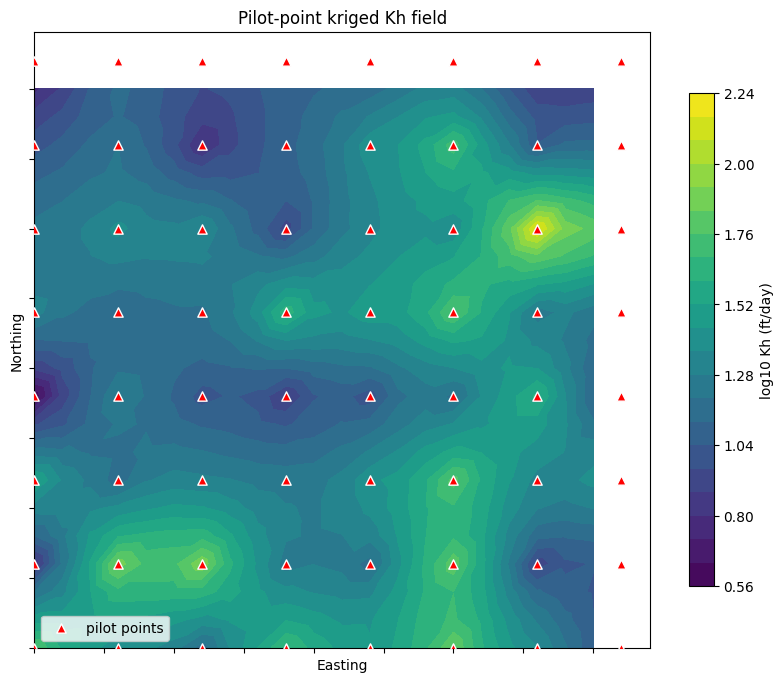

In [22]:
import matplotlib.pyplot as plt

from iwfm_io.plots import plot_contour_map

fig, ax, cs, cb = plot_contour_map(
    model, np.log10(kh_field.values), cmap="viridis",
    label="log10 Kh (ft/day)", title="Pilot-point kriged Kh field")
ax.scatter(pps["x"], pps["y"], marker="^", s=45, c="red",
           edgecolor="white", zorder=6, label="pilot points")
ax.legend()
plt.show()

## 7. Constrained reparameterization: `RatioChain`

Physical orderings (Kmax ≥ Kmin, coarse ≥ fine) break when PEST draws
each K independently. A `RatioChain` estimates an **anchor plus bounded
ratios/exponents**, so *every* draw honors the ordering — verified over
all bound corners by `assert_ordering`.

In [23]:
from iwfm_io.pest import RatioChain

chain = RatioChain()
chain.add_parameter("kxc", bounds=(20.0, 450.0), transform="log")
chain.add_parameter("dt", bounds=(0.7, 4.0))     # log10 decade span
chain.add_parameter("pa", bounds=(0.05, 0.95))
chain.add_parameter("pb", bounds=(0.05, 0.95))
chain.add_derived("kmax_coarse", "kxc")
chain.add_derived("kmin_coarse", "kxc * 10**(-pa*dt)")
chain.add_derived("kmax_fine", "kxc * 10**(-pb*dt)")
chain.add_derived("kmin_fine", "kxc * 10**(-dt)")

chain.assert_ordering([
    ("kmax_coarse", ">=", "kmin_coarse"),
    ("kmax_fine", ">=", "kmin_fine"),
    ("kmin_coarse", ">=", "kmin_fine"),
])
print("ordering guaranteed for every parameter draw")
chain.evaluate({"kxc": 100.0, "dt": 2.0, "pa": 0.5, "pb": 0.25})

ordering guaranteed for every parameter draw


{'kmax_coarse': 100.0,
 'kmin_coarse': 10.0,
 'kmax_fine': 31.622776601683793,
 'kmin_fine': 1.0}

In [24]:
# ready-made PEST parameter rows (log-space midpoint initials)
chain.par_data(name_format="{name}_z01")

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,partied
0,kxc_z01,log,factor,94.86833,20.00,450.00,kxc,1,0,1,
1,dt_z01,none,factor,2.35000,0.70,4.00,dt,1,0,1,
2,pa_z01,none,factor,0.50000,0.05,0.95,pa,1,0,1,
3,pb_z01,none,factor,0.50000,0.05,0.95,pb,1,0,1,


## 8. Paired output + instruction files: `ObsFileSpec`

The classic PEST failure mode is an `.ins` file that drifts out of sync
with the model's output writer. `ObsFileSpec` owns **both sides**: the
same spec writes the forward run's output file and the matching
instruction file, so they agree by construction — and
`verify_round_trip()` proves it.

In [25]:
from iwfm_io.pest import ObsFileSpec

head_names = paired["obsnme"].tolist()
spec = ObsFileSpec(head_names)
spec.verify_round_trip()

spec.write_ins(WORK / "heads.ins")
spec.write_output(paired["simulated"].to_numpy(), WORK / "heads.pout")
print("heads.ins:", (WORK / "heads.ins").read_text().splitlines()[:3])
print("heads.pout:", (WORK / "heads.pout").read_text().splitlines()[:2])

heads.ins: ['pif #', 'l1 [gwh_obs_a_19901115]20:35', 'l1 [gwh_obs_a_19910115]20:35']
heads.pout: ['gwh_obs_a_19901115   3.00222000E+02', 'gwh_obs_a_19910115   3.00230000E+02']


In [26]:
# the same spec builds the PEST observation-data table
obs_data = spec.obs_data(values=pd.Series(paired["observed"].values,
                                          index=head_names),
                         weight=1.0, group="gwh")
obs_data.head(3)

,obsnme,obsval,weight,obgnme
0,gwh_obs_a_19901115,300.679076,1.0,gwh
1,gwh_obs_a_19910115,298.670024,1.0,gwh
2,gwh_obs_a_19910317,301.374677,1.0,gwh


## 9. Weight balancing: phi budgets

Raw weights let one plentiful observation type dominate the objective.
`balance_weights` rescales group weights so each *category* contributes
a target phi (even or proportional split within the category), with
weight clipping and a full before/after report.

In [27]:
from iwfm_io.pest import balance_weights

bud_data = ObsFileSpec(bud_obs["obsnme"].tolist()).obs_data(
    values=pd.Series(bud_obs["value"].values, index=bud_obs["obsnme"]),
    weight=1e-6, group="bud")
all_obs = pd.concat([obs_data, bud_data], ignore_index=True)

residuals = pd.Series(
    np.r_[(paired["observed"] - paired["simulated"]).values,
          bud_obs["value"].values * 0.08],           # 8 % budget misfit
    index=all_obs["obsnme"])

wb = balance_weights(all_obs, residuals, {"gwh": 70.0, "bud": 30.0})
wb.report

,pattern,n_obs,n_nonzero,phi_before,target,factor,phi_after,share_before,share_after
obgnme,,,,,,,,,
bud,bud,9,9,136.156517,30.0,0.469398,30.0,0.309131,0.3
gwh,gwh,180,180,304.292853,70.0,0.479626,70.0,0.690869,0.7


## 10. `PestSetup` — the capstone

Accumulate parameter bundles + apply actions, observation tables +
specs, and run steps; `write()` emits a complete PEST++ v2 template
directory: control file, external tables, templates, instructions, and
a fail-fast `forward_run.py`.

In [28]:
import sys

from iwfm_io.pest import PestSetup

setup = PestSetup("sample_cal")
setup.add_parameters(bundle)
setup.add_observations(wb.obs_data[wb.obs_data["obgnme"] == "gwh"],
                       spec, output_file="heads.pout")

bud_spec = ObsFileSpec(bud_obs["obsnme"].tolist())
setup.add_observations(wb.obs_data[wb.obs_data["obgnme"] == "bud"],
                       bud_spec, output_file="budget.pout")

# the forward run: apply parameters -> run IWFM -> extract observations
setup.add_run_step("apply parameters", f'"{sys.executable}" apply_step.py')
setup.add_run_step("run iwfm", f'"{sys.executable}" run_step.py')
setup.add_run_step("extract observations", f'"{sys.executable}" extract_step.py')

template = setup.write(WORK / "pest_template")
sorted(p.name for p in template.iterdir())

['budget.pout.ins',
 'forward_run.py',
 'heads.pout.ins',
 'mult_kh.csv',
 'mult_kh.csv.tpl',
 'mult_strk.csv',
 'mult_strk.csv.tpl',
 'sample_cal.pst',
 'sample_cal_obs_data.csv',
 'sample_cal_par_data.csv',
 'sample_cal_pargp_data.csv']

In [29]:
print((template / "sample_cal.pst").read_text())

pcf version=2
* control data keyword
pestmode                       estimation
noptmax                        0
* parameter groups external
sample_cal_pargp_data.csv
* parameter data external
sample_cal_par_data.csv
* observation data external
sample_cal_obs_data.csv
* model command line
python forward_run.py
* model input
mult_strk.csv.tpl  mult_strk.csv
mult_kh.csv.tpl  mult_kh.csv
* model output
heads.pout.ins  heads.pout
budget.pout.ins  budget.pout



In [30]:
print((template / "forward_run.py").read_text()[:900], "...")

# -*- coding: utf-8 -*-
"""Forward run script - generated by iwfm_io.pest (fail-fast).
Interpreter hint: C:/Program Files/Python313/python.exe"""
import os, subprocess, sys, time
os.chdir(os.path.dirname(os.path.abspath(__file__)))
steps = [
    ('apply parameters', '"C:\\Program Files\\Python313\\python.exe" apply_step.py'),
    ('run iwfm', '"C:\\Program Files\\Python313\\python.exe" run_step.py'),
    ('extract observations', '"C:\\Program Files\\Python313\\python.exe" extract_step.py'),
]
for label, cmd in steps:
    t0 = time.time()
    print(f'forward_run: {label} ...', flush=True)
    rc = subprocess.call(cmd, shell=True)
    print(f'forward_run: {label} done rc={rc} ({time.time()-t0:.1f}s)', flush=True)
    if rc != 0:
        sys.exit(rc if rc else 1)
print('forward_run: all steps completed')
 ...


The three `*_step.py` scripts are yours to write from pieces shown
earlier — typically a few lines each:

- **apply_step.py** → `apply_parameters(run_dir, actions)` (§5), plus
  `apply_kriging_factors` for pilot-point fields (§6)
- **run_step.py** → `iwfm_io.run_model(run_dir)` (notebook 06)
- **extract_step.py** → extract series (notebook 08) and
  `spec.write_output(values, "heads.pout")` (§8)

## 11. Agents for parallel PEST++

PESTPP-IES runs one manager + many agents. `setup_agents` replicates
the template with **hardlinks** (instant, ~zero disk), empties the
Results folders, and drops a start script in each agent directory.

In [31]:
from iwfm_io.pest import setup_agents, write_manager_script

agents = setup_agents(template, 3, dest_root=WORK / "workers", port=4004)
print([a.name for a in agents])
script = next(agents[0].glob("start_agent.*"))
print(script.read_text())

['agent_01', 'agent_02', 'agent_03']
cd /d "C:\Users\serca\AppData\Local\Temp\iwfm_nb09_8ask48ra\workers\agent_01"
pestpp-ies sample_cal.pst /h localhost:4004



In [32]:
manager = write_manager_script(template, port=4004)
print(manager.read_text())

pestpp-ies sample_cal.pst /h :4004



In [33]:
shutil.rmtree(WORK, ignore_errors=True)
print("workspace removed")

workspace removed


## Recap — the build pipeline

```
metadata (nb 08) ──► observed SMP ──► match_sim_to_obs ──► obs names
                                                           + ObsFileSpec
ParamSpec/pilot points/RatioChain ──► build_parameters ──► templates
ApplyAction ──► apply_parameters            (forward-run write-back)
balance_weights ──► obs_data                (phi budgets)
PestSetup.write() ──► template dir ──► setup_agents ──► pestpp-ies
```

Notebook 10 picks up after the run: loading IES ensembles, statistics,
diagnostics, and figures.